In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern", "DejaVu Serif"]
})

cms = 1/2.54

ModuleNotFoundError: No module named 'google'

# 4. PCA

A Análise de Componentes Principais, ou Principal Component Analysis, PCA, é uma técnica estatística de transformação linear utilizada para reduzir a dimensionalidade de um conjunto de dados, preservando a maior parte possível da variabilidade presente nas variáveis originais.

Considere uma matriz de dados dada por:

$$
X \in \mathbb{R}^{n \times p}
$$

em que:

$$
n = \text{número de observações}
$$

$$
p = \text{número de variáveis}
$$

Cada linha da matriz representa uma observação, enquanto cada coluna representa uma variável. Antes da aplicação da PCA, normalmente os dados são centralizados em relação à média:

$$
X_c = X - \bar{X}
$$

em que $X_c$ é a matriz centralizada e $\bar{X}$ representa o vetor de médias das variáveis.

Quando as variáveis possuem escalas ou unidades diferentes, recomenda-se utilizar a padronização dos dados:

$$
Z = \frac{X - \mu}{\sigma}
$$

em que $\mu$ é a média de cada variável e $\sigma$ é o respectivo desvio padrão. Após esse procedimento, cada variável passa a ter média zero e desvio padrão igual a um.

A PCA é baseada na matriz de covariância dos dados centralizados, definida por:

$$
S = \frac{1}{n-1}X_c^T X_c
$$

Essa matriz contém, na diagonal principal, as variâncias das variáveis originais e, fora da diagonal principal, as covariâncias entre pares de variáveis.

O objetivo da PCA é encontrar novas direções no espaço dos dados, chamadas componentes principais, que maximizem sucessivamente a variância projetada dos dados. Isso é feito resolvendo o seguinte problema de autovalores e autovetores:

$$
S v_i = \lambda_i v_i
$$

em que:

$$
v_i = \text{autovetor associado à i-ésima componente principal}
$$

$$
\lambda_i = \text{autovalor associado à i-ésima componente principal}
$$

Os autovetores definem as direções das componentes principais, enquanto os autovalores indicam a quantidade de variância explicada por cada componente.

A primeira componente principal é definida como a direção que maximiza a variância dos dados projetados. Formalmente:

$$
v_1 = \arg\max_{\|v\|=1} \text{Var}(X_c v)
$$

Como a variância projetada pode ser escrita como:

$$
\text{Var}(X_c v) = v^T S v
$$

tem-se:

$$
v_1 = \arg\max_{\|v\|=1} v^T S v
$$

A solução desse problema é o autovetor associado ao maior autovalor da matriz de covariância.

A segunda componente principal é obtida de modo semelhante, porém com a restrição de ser ortogonal à primeira componente:

$$
v_2^T v_1 = 0
$$

De forma geral, as componentes principais são ortogonais entre si e não correlacionadas. A primeira componente explica a maior parcela da variância dos dados, a segunda componente explica a maior parcela da variância restante, e assim sucessivamente.

Após a obtenção dos autovetores, os dados podem ser projetados no novo sistema de coordenadas:

$$
T = X_c V
$$

em que:

$$
T = \text{matriz de scores}
$$

$$
V = \text{matriz de loadings}
$$

Os scores representam as coordenadas das observações no espaço das componentes principais. Os loadings representam os pesos das variáveis originais em cada componente principal.

Uma componente principal pode ser escrita como uma combinação linear das variáveis originais:

$$
PC_1 = a_1x_1 + a_2x_2 + a_3x_3 + \cdots + a_px_p
$$

em que $x_1, x_2, \ldots, x_p$ são as variáveis originais e $a_1, a_2, \ldots, a_p$ são os coeficientes, ou pesos, associados a cada variável.

Por exemplo:

$$
PC_1 = 0.60x_1 + 0.55x_2 - 0.10x_3 + 0.57x_4
$$

Nesse caso, as variáveis $x_1$, $x_2$ e $x_4$ apresentam maior contribuição para a primeira componente principal, enquanto $x_3$ apresenta menor contribuição relativa.

A fração da variância explicada pela componente principal $i$ é dada por:

$$
EVR_i = \frac{\lambda_i}{\sum_{j=1}^{p}\lambda_j}
$$

em que $EVR_i$ representa o explained variance ratio da componente $i$.

A variância explicada acumulada até a componente $k$ é dada por:

$$
EVR_{\text{acum}}(k) = \frac{\sum_{i=1}^{k}\lambda_i}{\sum_{j=1}^{p}\lambda_j}
$$

Esse critério é utilizado para definir quantas componentes principais devem ser mantidas na análise. Por exemplo, se as três primeiras componentes explicam 95% da variância total, pode-se substituir as $p$ variáveis originais por apenas três componentes, preservando grande parte da informação estatística dos dados.

A PCA também pode ser interpretada como um problema de reconstrução dos dados. Ao manter apenas $k < p$ componentes principais, obtém-se uma aproximação da matriz original centralizada:

$$
\hat{X}_c = T_k V_k^T
$$

em que $T_k$ é a matriz de scores considerando apenas as $k$ primeiras componentes e $V_k$ é a matriz de loadings correspondente.

A PCA escolhe as direções que minimizam o erro quadrático de reconstrução:

$$
\|X_c - \hat{X}_c\|_F^2
$$

Assim, entre todas as possíveis projeções lineares em $k$ dimensões, a PCA fornece aquela que preserva a maior variância dos dados e minimiza a perda de informação no sentido dos mínimos quadrados.

Computacionalmente, a PCA também pode ser obtida por meio da decomposição em valores singulares, ou Singular Value Decomposition, SVD:

$$
X_c = U \Sigma V^T
$$

Nesse caso, as colunas de $V$ representam as direções principais, enquanto os autovalores da matriz de covariância podem ser obtidos por:

$$
\lambda_i = \frac{\sigma_i^2}{n-1}
$$

em que $\sigma_i$ são os valores singulares da matriz $X_c$.

A formulação via SVD é frequentemente utilizada em implementações computacionais por apresentar maior estabilidade numérica, principalmente quando o número de variáveis é elevado ou quando há colinearidade entre as variáveis originais.

Em termos práticos, a PCA é útil quando existe correlação entre variáveis. Quando variáveis diferentes carregam informações semelhantes, a PCA reorganiza essa informação em componentes não correlacionadas e ordenadas de acordo com a variância explicada.

No entanto, algumas limitações devem ser consideradas. A PCA é uma técnica linear, portanto não captura relações não lineares complexas. Além disso, a técnica maximiza variância, mas isso não significa necessariamente que as primeiras componentes sejam as mais relevantes para problemas de classificação, diagnóstico ou prognóstico. Uma variável com baixa variância pode ser importante para detectar uma falha ou uma condição específica de operação.

Além disso, a PCA é sensível à escala das variáveis e à presença de outliers. Por isso, a padronização dos dados e a análise prévia de valores extremos são etapas importantes antes da aplicação da técnica.

A PCA transforma um conjunto de variáveis originais em uma nova base ortogonal formada pelas componentes principais. Essas componentes são combinações lineares das variáveis originais, ordenadas de acordo com a variância explicada. A técnica permite reduzir dimensionalidade, remover redundância linear, visualizar dados de alta dimensão e construir variáveis latentes que preservam a maior parte da variabilidade estatística dos dados.

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
arquivo = files.upload()
arquivo.keys()

Saving DadosNotas.xlsx to DadosNotas (2).xlsx


dict_keys(['DadosNotas (2).xlsx'])

In [4]:
df = pd.read_excel(list(arquivo.keys())[0])
df

,finanças,custos,marketing,atuária
0,5.8,4.0,1.0,6.0
1,3.1,3.0,10.0,2.0
2,3.1,4.0,4.0,4.0
3,10.0,8.0,8.0,8.0
4,3.4,2.0,3.2,3.2
...,...,...,...,...
95,7.7,4.3,5.2,5.1
96,9.0,6.0,4.0,9.8
97,9.3,6.0,7.0,7.0
98,9.0,6.5,3.0,9.0


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [6]:
# PCA keeping 95% of variance
#PCA(n_components=0.95)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

In [7]:
# Number of components retained
n_components_retained = pca.n_components_
n_components_retained

np.int64(3)

In [8]:
X_pca.shape

(100, 3)

In [9]:
# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

In [10]:
explained_variance

array([0.6295317 , 0.25009482, 0.07440396])

In [11]:
cumulative_variance

array([0.6295317 , 0.87962653, 0.95403049])

In [12]:
# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=df.columns,
    columns=[f"PC{i+1}" for i in range(n_components_retained)]
)

In [13]:
loadings

,PC1,PC2,PC3
finanças,0.564257,0.007084,0.800525
custos,0.588604,0.048571,-0.219567
marketing,-0.026761,0.998743,-0.000657
atuária,0.578310,-0.010131,-0.557628


In [14]:
# Reduced dataset
df_reduced = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(n_components_retained)]
)

In [15]:
df_reduced

,PC1,PC2,PC3
0,0.024172,-1.673770,-0.096231
1,-1.717726,1.510482,0.187913
2,-0.957243,-0.607130,-0.346554
3,2.146365,0.891490,0.178821
4,-1.561913,-0.926875,0.089034
...,...,...,...
95,0.193386,-0.169259,0.566065
96,1.937369,-0.577425,-0.299603
97,1.315739,0.499296,0.401413
98,1.882288,-0.919143,-0.165888


# 5. Método não hierárquico (K-means)

O agrupamento não hierárquico, ou non-hierarchical clustering, é uma técnica de aprendizado não supervisionado utilizada para dividir um conjunto de dados em grupos, chamados clusters, de modo que observações pertencentes ao mesmo grupo sejam mais semelhantes entre si do que observações pertencentes a grupos diferentes.

Diferentemente do agrupamento hierárquico, o agrupamento não hierárquico não constrói uma estrutura em árvore, como um dendrograma. Em vez disso, ele busca diretamente uma partição dos dados em um número definido de grupos. Em muitos métodos não hierárquicos, o número de clusters deve ser especificado antes da aplicação do algoritmo.

Considere uma matriz de dados:

$$
X \in \mathbb{R}^{n \times p}
$$

em que:

$$
n = \text{número de observações}
$$

$$
p = \text{número de variáveis}
$$

Cada linha da matriz representa uma observação, enquanto cada coluna representa uma variável. O objetivo do agrupamento não hierárquico é particionar as $n$ observações em $K$ clusters:

$$
C_1, C_2, \ldots, C_K
$$

de modo que:

$$
C_i \cap C_j = \emptyset, \quad i \neq j
$$

e:

$$
\bigcup_{k=1}^{K} C_k = X
$$

Isso significa que cada observação pertence a apenas um cluster e que todos os dados são alocados em algum grupo.

Um dos métodos mais utilizados de agrupamento não hierárquico é o K-Means. O K-Means busca dividir os dados em $K$ grupos, minimizando a variabilidade interna dos clusters. Para isso, cada cluster é representado por um centroide, que corresponde ao vetor médio das observações pertencentes ao grupo.

O centroide do cluster $C_k$ é dado por:

$$
\mu_k = \frac{1}{|C_k|}\sum_{x_i \in C_k}x_i
$$

em que:

$$
\mu_k = \text{centroide do cluster } k
$$

$$
|C_k| = \text{número de observações no cluster } k
$$

$$
x_i = \text{observação pertencente ao cluster } C_k
$$

O objetivo do K-Means é minimizar a soma dos quadrados das distâncias entre cada observação e o centroide do cluster ao qual ela pertence. A função objetivo pode ser escrita como:

$$
J = \sum_{k=1}^{K}\sum_{x_i \in C_k}\|x_i - \mu_k\|^2
$$

em que $J$ representa a soma dos quadrados intra-cluster. Quanto menor o valor de $J$, mais compactos são os clusters formados.

O algoritmo K-Means pode ser descrito pelas seguintes etapas:

1. Define-se previamente o número de clusters $K$.
2. Inicializam-se $K$ centroides, de forma aleatória ou por algum critério específico.
3. Cada observação é atribuída ao cluster cujo centroide está mais próximo.
4. Os centroides são recalculados com base nas observações atribuídas a cada cluster.
5. As etapas de atribuição e atualização dos centroides são repetidas até a convergência.

A atribuição de uma observação $x_i$ a um cluster é feita pela menor distância em relação aos centroides:

$$
c_i = \arg\min_{k}\|x_i - \mu_k\|^2
$$

em que $c_i$ representa o cluster atribuído à observação $x_i$.

Após essa atribuição, os centroides são atualizados por:

$$
\mu_k = \frac{1}{|C_k|}\sum_{x_i \in C_k}x_i
$$

O processo iterativo continua até que os centroides não mudem significativamente, ou até que as observações permaneçam nos mesmos clusters entre duas iterações consecutivas. Também pode ser utilizado um número máximo de iterações como critério de parada.

A distância mais frequentemente utilizada no K-Means é a distância euclidiana:

$$
d(x_i,\mu_k) = \sqrt{\sum_{j=1}^{p}(x_{ij}-\mu_{kj})^2}
$$

em que $x_{ij}$ é o valor da variável $j$ na observação $i$, e $\mu_{kj}$ é o valor da variável $j$ no centroide do cluster $k$.

Como o K-Means depende da distância euclidiana, ele é sensível à escala das variáveis. Por isso, quando as variáveis possuem unidades ou magnitudes diferentes, recomenda-se padronizar os dados antes da aplicação do método:

$$
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$

em que:

$$
\mu_j = \text{média da variável } j
$$

$$
\sigma_j = \text{desvio padrão da variável } j
$$

Após a padronização, cada variável passa a ter média zero e desvio padrão igual a um, reduzindo o efeito de dominância de variáveis com maior escala numérica.

Uma questão importante no agrupamento não hierárquico é a escolha do número de clusters $K$. Um método bastante utilizado é o método do cotovelo, ou elbow method. Nesse método, calcula-se a soma dos quadrados intra-cluster para diferentes valores de $K$:

$$
W(K) = \sum_{k=1}^{K}\sum_{x_i \in C_k}\|x_i - \mu_k\|^2
$$

À medida que $K$ aumenta, o valor de $W(K)$ tende a diminuir, pois os clusters se tornam menores e mais compactos. No entanto, após certo ponto, o ganho obtido pela adição de novos clusters passa a ser pequeno. Esse ponto é chamado de cotovelo e pode ser usado como indicação do número adequado de grupos.

Outro critério utilizado para avaliar a qualidade da clusterização é o coeficiente de silhueta, ou silhouette score. Para cada observação $x_i$, define-se:

$$
a(i) = \text{distância média entre } x_i \text{ e as demais observações do mesmo cluster}
$$

$$
b(i) = \text{menor distância média entre } x_i \text{ e as observações dos demais clusters}
$$

O coeficiente de silhueta da observação $i$ é dado por:

$$
s(i) = \frac{b(i)-a(i)}{\max(a(i),b(i))}
$$

O valor de $s(i)$ varia entre $-1$ e $1$. Valores próximos de $1$ indicam que a observação está bem alocada em seu cluster. Valores próximos de $0$ indicam que a observação está próxima da fronteira entre dois clusters. Valores negativos indicam que a observação pode ter sido atribuída a um cluster inadequado.

O coeficiente de silhueta médio pode ser utilizado para comparar diferentes valores de $K$:

$$
S = \frac{1}{n}\sum_{i=1}^{n}s(i)
$$

Um valor maior de $S$ indica, em geral, uma melhor separação entre os clusters.

Além do K-Means, existem outros métodos de agrupamento não hierárquico. Um exemplo é o K-Medoids, que é semelhante ao K-Means, mas utiliza observações reais como representantes dos clusters, chamadas medoides. Enquanto o centroide pode ser um ponto médio que não existe originalmente no conjunto de dados, o medoide é sempre uma observação real.

No K-Medoids, o objetivo é minimizar a soma das distâncias entre as observações e os medoides:

$$
J = \sum_{k=1}^{K}\sum_{x_i \in C_k}d(x_i,m_k)
$$

em que $m_k$ representa o medoide do cluster $k$. Esse método tende a ser mais robusto à presença de outliers do que o K-Means, pois utiliza pontos reais como centros dos grupos.

Outro método não hierárquico é o DBSCAN, Density-Based Spatial Clustering of Applications with Noise. Diferentemente do K-Means, o DBSCAN não exige a definição prévia do número de clusters. Ele forma grupos com base na densidade local dos pontos e pode identificar observações como ruído ou outliers.

O DBSCAN utiliza dois parâmetros principais:

$$
\varepsilon = \text{raio de vizinhança}
$$

$$
MinPts = \text{número mínimo de pontos em uma vizinhança}
$$

A vizinhança de uma observação \(x_i\) é definida por:

$$
N_{\varepsilon}(x_i) = \{x_j \in X : d(x_i,x_j) \leq \varepsilon\}
$$

Uma observação é considerada ponto central, ou core point, se:

$$
|N_{\varepsilon}(x_i)| \geq MinPts
$$

Pontos centrais conectados por regiões de alta densidade formam clusters. Observações que não pertencem a nenhuma região densa podem ser classificadas como ruído. O DBSCAN é útil quando os clusters possuem formas irregulares e quando há outliers no conjunto de dados.

Apesar da existência de diferentes métodos não hierárquicos, o K-Means é um dos mais utilizados devido à sua simplicidade, eficiência computacional e facilidade de interpretação. No entanto, ele apresenta algumas limitações importantes. O método exige a definição prévia do número de clusters, é sensível à inicialização dos centroides, pode convergir para mínimos locais, é afetado por outliers e tende a apresentar melhor desempenho quando os clusters possuem formato aproximadamente esférico e tamanhos semelhantes.

Para reduzir a influência da inicialização aleatória, pode-se executar o K-Means várias vezes com diferentes centroides iniciais e selecionar a solução com menor valor da função objetivo $J$. Uma estratégia comum é utilizar o método K-Means++, que escolhe os centroides iniciais de forma mais espaçada, aumentando a chance de uma clusterização mais estável.

Em aplicações de engenharia, o agrupamento não hierárquico pode ser utilizado para identificar padrões operacionais, separar regimes de funcionamento de máquinas, agrupar sensores com comportamento semelhante, classificar regiões estruturais com características próximas ou organizar dados de degradação em grupos representativos.

Por exemplo, em um banco de dados de sensores de uma unidade geradora, variáveis como potência, vazão, temperatura, vibração e pressão podem ser usadas para identificar diferentes condições operacionais. O agrupamento não hierárquico pode separar automaticamente regiões do espaço de dados associadas a operação normal, operação com restrição, baixa carga, alta carga ou padrões anômalos.

https://scikit-learn.org/stable/

In [16]:
from sklearn.cluster import KMeans

In [17]:
dfC = df.copy()

# Não realizando a padronização das variáveis

In [18]:
kmeans = KMeans(n_clusters=2, n_init=1)#,random_state=42)
dfC['C1'] = kmeans.fit_predict(dfC)
dfC['C2'] = kmeans.fit_predict(dfC)
dfC['C3'] = kmeans.fit_predict(dfC)

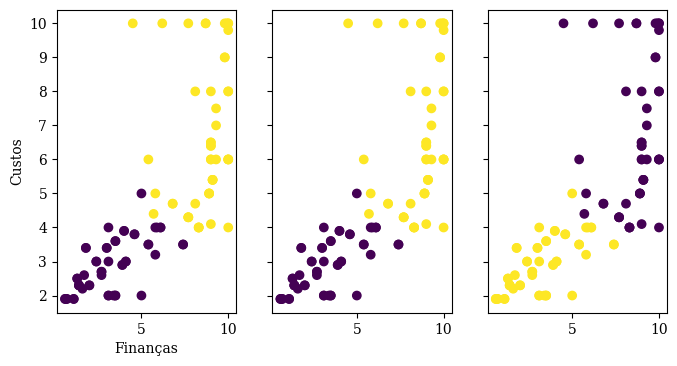

In [19]:
cms=1/2.54
fig, ax = plt.subplots(1,3,figsize=(20*cms,10*cms), sharey=True)
ax[0].scatter(dfC["finanças"], dfC["custos"], c=dfC["C1"])
ax[1].scatter(dfC["finanças"], dfC["custos"], c=dfC["C2"])
ax[2].scatter(dfC["finanças"], dfC["custos"], c=dfC["C3"])
ax[0].set_xlabel("Finanças")
ax[0].set_ylabel("Custos")
plt.show()

# Realizando a padronização das variáveis

In [20]:
scaler1 = StandardScaler()
X =  scaler1.fit_transform(dfC)
dfC1 = pd.DataFrame(X,columns=dfC.columns)

In [21]:
kmeans = KMeans(n_clusters=2, n_init=1)#,random_state=42)
dfC1['C1'] = kmeans.fit_predict(dfC1)
dfC1['C2'] = kmeans.fit_predict(dfC1)
dfC1['C3'] = kmeans.fit_predict(dfC1)

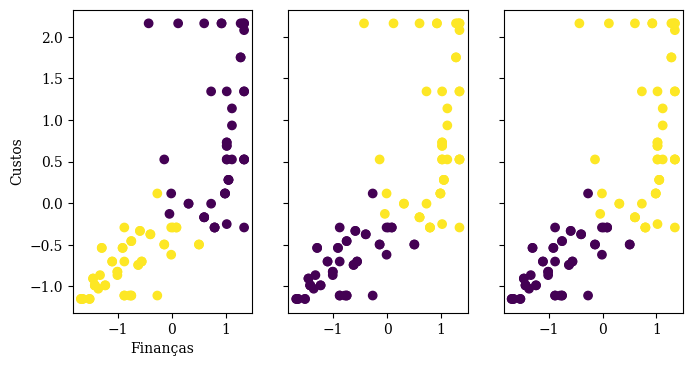

In [22]:
cms=1/2.54
fig, ax = plt.subplots(1,3,figsize=(20*cms,10*cms), sharey=True)
ax[0].scatter(dfC1["finanças"], dfC1["custos"], c=dfC1["C1"])
ax[1].scatter(dfC1["finanças"], dfC1["custos"], c=dfC1["C2"])
ax[2].scatter(dfC1["finanças"], dfC1["custos"], c=dfC1["C3"])
ax[0].set_xlabel("Finanças")
ax[0].set_ylabel("Custos")
plt.show()

# Curva do Cotovelo e Variáveis Numéricas

In [23]:
arquivo1 = files.upload()

Saving DadosCoracao.xlsx to DadosCoracao (2).xlsx


In [24]:
dfN = pd.read_excel(list(arquivo1.keys())[0])
dfN

,Idade,Sexo,DorPeito,PSDescanso,Colesterol,AcucarSangue,ECGDescanso,BCMax,AnginaExercicio,DoencaCard
0,40,Masculino,Atipica,140,289,Normal,Normal,172,Nao,Nao
1,49,Feminino,Sem_Dor,160,180,Normal,Normal,156,Nao,Sim
2,37,Masculino,Atipica,130,283,Normal,Anormal_ST,98,Nao,Nao
3,48,Feminino,Assintomatico,138,214,Normal,Normal,108,Sim,Sim
4,54,Masculino,Sem_Dor,150,195,Normal,Normal,122,Nao,Nao
...,...,...,...,...,...,...,...,...,...,...
913,45,Masculino,Tipica,110,264,Normal,Normal,132,Nao,Sim
914,68,Masculino,Assintomatico,144,193,Diabetes,Normal,141,Nao,Sim
915,57,Masculino,Assintomatico,130,131,Normal,Normal,115,Sim,Sim
916,57,Feminino,Atipica,130,236,Normal,Hipertrofia_VE,174,Nao,Sim


In [25]:
dfNN = dfN.select_dtypes(include="number")
dfNN

,Idade,PSDescanso,Colesterol,BCMax
0,40,140,289,172
1,49,160,180,156
2,37,130,283,98
3,48,138,214,108
4,54,150,195,122
...,...,...,...,...
913,45,110,264,132
914,68,144,193,141
915,57,130,131,115
916,57,130,236,174


In [26]:
# Elbow method
inertias = []
k_values = range(1, 12)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(dfNN)
    inertias.append(kmeans.inertia_)

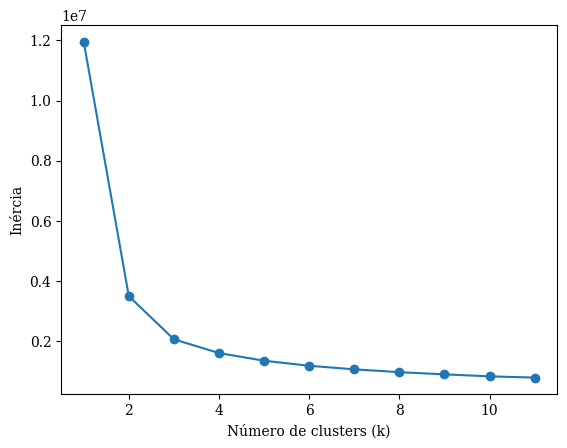

In [27]:
# Plot elbow curve
plt.figure()
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.show()

In [28]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
dfNN["C3"] = kmeans.fit_predict(dfNN)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
dfNN["C4"] = kmeans.fit_predict(dfNN)

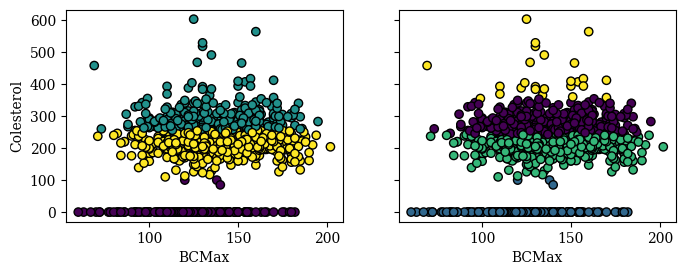

In [29]:
fig,ax = plt.subplots(1,2,figsize=(20*cms,7*cms),sharey=True)


ax[0].scatter(dfNN["BCMax"], dfNN["Colesterol"],c=dfNN["C3"],edgecolor='black')
ax[1].scatter(dfNN["BCMax"], dfNN["Colesterol"],c=dfNN["C4"],edgecolor='black')
ax[0].set_xlabel("BCMax")
ax[1].set_xlabel("BCMax")
ax[0].set_ylabel("Colesterol")
plt.show()

# K-medoids e a distância de Gower

In [30]:
!pip install gower
import gower

In [31]:
!pip install kmedoids
import kmedoids

In [32]:
D = gower.gower_matrix(dfN)
D

array([[0.        , 0.35771123, 0.16423015, ..., 0.40603703, 0.34989172,
        0.12469133],
       [0.35771123, 0.        , 0.49741614, ..., 0.3683258 , 0.2532895 ,
        0.24625   ],
       [0.16423015, 0.49741614, 0.        , ..., 0.47799546, 0.40213183,
        0.27676818],
       ...,
       [0.40603703, 0.3683258 , 0.47799546, ..., 0.        , 0.45896223,
        0.39091742],
       [0.34989172, 0.2532895 , 0.40213183, ..., 0.45896223, 0.        ,
        0.45359582],
       [0.12469133, 0.24625   , 0.27676818, ..., 0.39091742, 0.45359582,
        0.        ]], dtype=float32)

In [33]:
model = kmedoids.KMedoids(
    n_clusters=3,
    method="fasterpam",
    random_state=42
)

result = model.fit(D)

dfN["C1"] = result.labels_

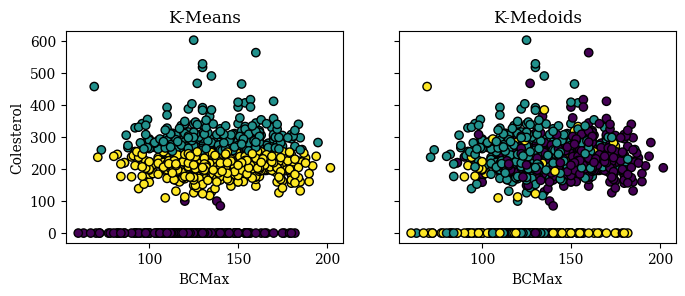

In [34]:
fig,ax = plt.subplots(1,2,figsize=(20*cms,7*cms),sharey=True)


ax[0].scatter(dfNN["BCMax"], dfNN["Colesterol"],c=dfNN["C3"],edgecolor='black')
ax[1].scatter(dfN["BCMax"], dfN["Colesterol"],c=dfN["C1"],edgecolor='black')
ax[0].set_xlabel("BCMax")
ax[1].set_xlabel("BCMax")
ax[0].set_ylabel("Colesterol")

ax[0].set_title("K-Means")
ax[1].set_title("K-Medoids")
plt.show()

# 6. AGRUPAMENTO HIERÁRQUICO

O agrupamento hierárquico, ou hierarchical clustering, é uma técnica de aprendizado não supervisionado utilizada para organizar observações em grupos com base em uma medida de similaridade ou dissimilaridade. Diferentemente de métodos particionais, como o K-Means, o agrupamento hierárquico não exige necessariamente que o número de grupos seja definido previamente. Em vez disso, ele constrói uma estrutura hierárquica de agrupamento, normalmente representada por um dendrograma.

Considere uma matriz de dados:

$$
X \in \mathbb{R}^{n \times p}
$$

em que:

$$
n = \text{número de observações}
$$

$$
p = \text{número de variáveis}
$$

Cada linha da matriz representa uma observação, enquanto cada coluna representa uma variável. O objetivo do agrupamento hierárquico é agrupar observações semelhantes entre si, de modo que elementos dentro do mesmo grupo apresentem maior similaridade do que elementos pertencentes a grupos diferentes.

A etapa inicial consiste em definir uma medida de distância entre as observações. Uma das métricas mais utilizadas é a distância euclidiana:

$$
d(x_i,x_j) = \sqrt{\sum_{k=1}^{p}(x_{ik}-x_{jk})^2}
$$

em que $x_i$ e $x_j$ são duas observações do conjunto de dados, e $x_{ik}$ e $x_{jk}$ representam os valores dessas observações na variável $k$.

Também podem ser utilizadas outras métricas, como distância Manhattan, distância de Mahalanobis, distância cosseno ou distância de correlação, dependendo da natureza dos dados e do objetivo da análise.

No agrupamento hierárquico aglomerativo, cada observação inicia como um grupo individual. Em seguida, os grupos mais semelhantes são combinados iterativamente até que todas as observações pertençam a um único grupo. Esse processo pode ser descrito pelas seguintes etapas:

1. Inicialmente, cada observação é considerada um cluster independente.
2. Calcula-se a matriz de distâncias entre todos os pares de clusters.
3. Identificam-se os dois clusters mais próximos.
4. Esses dois clusters são combinados em um novo cluster.
5. A matriz de distâncias é atualizada.
6. O processo é repetido até que reste apenas um cluster contendo todas as observações.

A principal questão técnica do agrupamento hierárquico é definir como calcular a distância entre dois grupos. Essa definição é chamada de critério de ligação, ou linkage criterion.

No método de ligação simples, single linkage, a distância entre dois clusters é definida como a menor distância entre quaisquer dois pontos pertencentes aos clusters:

$$
D(A,B) = \min_{x_i \in A, x_j \in B} d(x_i,x_j)
$$

Esse método tende a formar clusters alongados, pois a fusão entre grupos pode ocorrer devido à proximidade entre apenas dois pontos. Esse comportamento é conhecido como efeito de encadeamento.

No método de ligação completa, complete linkage, a distância entre dois clusters é definida como a maior distância entre quaisquer dois pontos pertencentes aos clusters:

$$
D(A,B) = \max_{x_i \in A, x_j \in B} d(x_i,x_j)
$$

Esse critério tende a gerar clusters mais compactos, pois considera a maior separação entre os elementos dos grupos.

No método de ligação média, average linkage, a distância entre dois clusters é definida como a média das distâncias entre todos os pares de pontos pertencentes aos clusters:

$$
D(A,B) = \frac{1}{|A||B|}\sum_{x_i \in A}\sum_{x_j \in B}d(x_i,x_j)
$$

em que $|A|$ e $|B|$ representam o número de observações nos clusters $A$ e $B$, respectivamente.

Outro critério bastante utilizado é o método de Ward. Nesse caso, a fusão entre clusters é escolhida de modo a minimizar o aumento da variância interna dos grupos. O método de Ward procura formar clusters compactos e aproximadamente esféricos. A ideia é combinar os grupos cuja fusão gera o menor aumento na soma dos quadrados intra-cluster.

A soma dos quadrados intra-cluster pode ser escrita como:

$$
W = \sum_{g=1}^{G}\sum_{x_i \in C_g}\|x_i - \mu_g\|^2
$$

em que:

$$
G = \text{número de clusters}
$$

$$
C_g = \text{cluster } g
$$

$$
\mu_g = \text{centroide do cluster } g
$$

O método de Ward escolhe, em cada etapa, a fusão que gera o menor incremento em $W$. Esse critério é especialmente adequado quando se utiliza distância euclidiana e quando se deseja obter grupos com baixa dispersão interna.

O resultado do agrupamento hierárquico é geralmente representado por um dendrograma. O dendrograma é uma estrutura em árvore que mostra a sequência de fusões entre os clusters. No eixo horizontal, aparecem as observações ou grupos. No eixo vertical, aparece a distância, ou dissimilaridade, na qual as fusões ocorreram.

A altura em que dois clusters se unem no dendrograma indica o nível de dissimilaridade entre eles. Fusões em alturas baixas indicam grupos muito semelhantes. Fusões em alturas elevadas indicam grupos mais diferentes.

A definição final do número de clusters pode ser feita cortando o dendrograma em uma determinada altura. Se o corte for feito em uma altura baixa, obtêm-se muitos clusters pequenos. Se o corte for feito em uma altura alta, obtêm-se poucos clusters maiores.

Matematicamente, a escolha do número de clusters pode ser interpretada como a seleção de um nível de corte $h$ no dendrograma:

$$
G = f(h)
$$

em que $G$ é o número de grupos resultantes e $h$ é a altura de corte. Quanto maior o valor de $h$, menor tende a ser o número de clusters obtidos.

Antes da aplicação do agrupamento hierárquico, é comum realizar a padronização dos dados, principalmente quando as variáveis possuem unidades ou escalas diferentes. A padronização pode ser feita por:

$$
z_{ik} = \frac{x_{ik} - \mu_k}{\sigma_k}
$$

em que $\mu_k$ é a média da variável $k$ e $\sigma_k$ é o seu desvio padrão. Após a padronização, cada variável passa a ter média zero e desvio padrão igual a um.

Essa etapa é importante porque medidas de distância, como a distância euclidiana, são sensíveis à escala das variáveis. Se uma variável possui valores numericamente muito maiores que as demais, ela pode dominar o cálculo da distância e influenciar indevidamente a formação dos clusters.

O agrupamento hierárquico apresenta algumas vantagens. Ele permite visualizar a estrutura dos dados em diferentes níveis de agrupamento, não exige a definição prévia do número de clusters e fornece uma representação interpretável por meio do dendrograma. Além disso, pode ser aplicado com diferentes métricas de distância e diferentes critérios de ligação.

No entanto, também apresenta limitações. O método pode ser sensível à presença de outliers, à escolha da métrica de distância e ao critério de linkage. Além disso, seu custo computacional pode ser elevado para bases de dados muito grandes, pois depende do cálculo e atualização de matrizes de distância entre observações ou grupos.

Em termos práticos, o agrupamento hierárquico é útil quando se deseja compreender a estrutura interna dos dados, identificar grupos naturais, comparar padrões de similaridade entre observações ou analisar relações entre amostras sem uma variável resposta. Em aplicações de engenharia, por exemplo, pode ser utilizado para agrupar condições operacionais semelhantes, identificar padrões em sensores, separar regiões estruturais com comportamento parecido ou classificar observações de degradação com base em características medidas.

In [35]:
import os
from PIL import Image
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
from tqdm import tqdm
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from collections import defaultdict
from PIL import Image

### Funções para trabalhar com as imagens

In [36]:
device = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std =(0.229, 0.224, 0.225)),
])

In [37]:
class ImageListDS(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert("RGB")
        x = self.transform(img)
        return x, os.path.basename(p)



In [38]:
deeplab = torchvision.models.segmentation.deeplabv3_resnet50(
    weights=torchvision.models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT
).to(device).eval()

@torch.no_grad()
def extract_embeddings(dataloader, model, device):
    embs = []
    names = []
    for x, name in tqdm(dataloader):
        x = x.to(device)

        feats = model.backbone(x)["out"]          # [B, C, H, W]
        vec = F.adaptive_avg_pool2d(feats, 1)     # [B, C, 1, 1]
        vec = vec.flatten(1)                      # [B, C]
        vec = F.normalize(vec, p=2, dim=1)        # normaliza (bom p/ cosine)

        embs.append(vec.cpu().numpy())
        names += list(name)

    return np.vstack(embs), names

In [39]:
arquivos2 = files.upload()
arquivos2.keys()

Saving 1.jpg to 1 (1).jpg
Saving 2.jpg to 2 (1).jpg
Saving 3.jpg to 3 (1).jpg
Saving 4.jpg to 4 (1).jpg
Saving 5.jpg to 5 (1).jpg
Saving 6.jpg to 6 (1).jpg
Saving 7.jpg to 7 (1).jpg
Saving 8.jpg to 8 (1).jpg


dict_keys(['1 (1).jpg', '2 (1).jpg', '3 (1).jpg', '4 (1).jpg', '5 (1).jpg', '6 (1).jpg', '7 (1).jpg', '8 (1).jpg'])

In [40]:
img_paths = [os.path.join("/content", fname) for fname in arquivos2.keys()]
img_paths = sorted(img_paths)
img_paths

['/content/1 (1).jpg',
 '/content/2 (1).jpg',
 '/content/3 (1).jpg',
 '/content/4 (1).jpg',
 '/content/5 (1).jpg',
 '/content/6 (1).jpg',
 '/content/7 (1).jpg',
 '/content/8 (1).jpg']

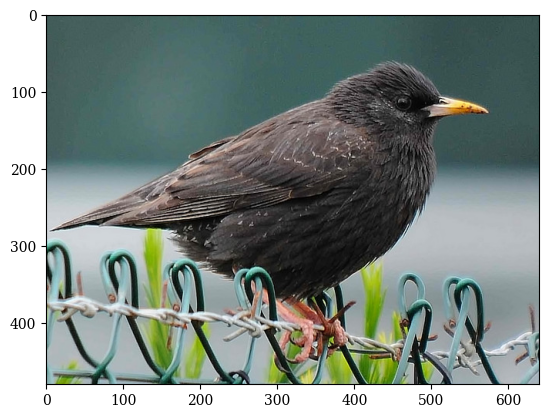

In [41]:
plt.imshow(Image.open(img_paths[7]).convert("RGB"))

In [42]:
ds = ImageListDS(img_paths, transform)
dl = DataLoader(ds, batch_size=4, shuffle=False)

embeddings, names = extract_embeddings(dl, deeplab, device)
embeddings.shape, names

100%|██████████| 2/2 [00:18<00:00,  9.24s/it]


((8, 2048),
 ['1 (1).jpg',
  '2 (1).jpg',
  '3 (1).jpg',
  '4 (1).jpg',
  '5 (1).jpg',
  '6 (1).jpg',
  '7 (1).jpg',
  '8 (1).jpg'])

In [43]:
Z = linkage(embeddings, method="single", metric="cosine")

In [44]:
Z

array([[ 4.        ,  5.        ,  0.04217614,  2.        ],
       [ 6.        ,  8.        ,  0.04987165,  3.        ],
       [ 7.        ,  9.        ,  0.05714981,  4.        ],
       [ 1.        ,  3.        ,  0.0739569 ,  2.        ],
       [ 0.        ,  2.        ,  0.14311847,  2.        ],
       [11.        , 12.        ,  0.17424843,  4.        ],
       [10.        , 13.        ,  0.18032312,  8.        ]])

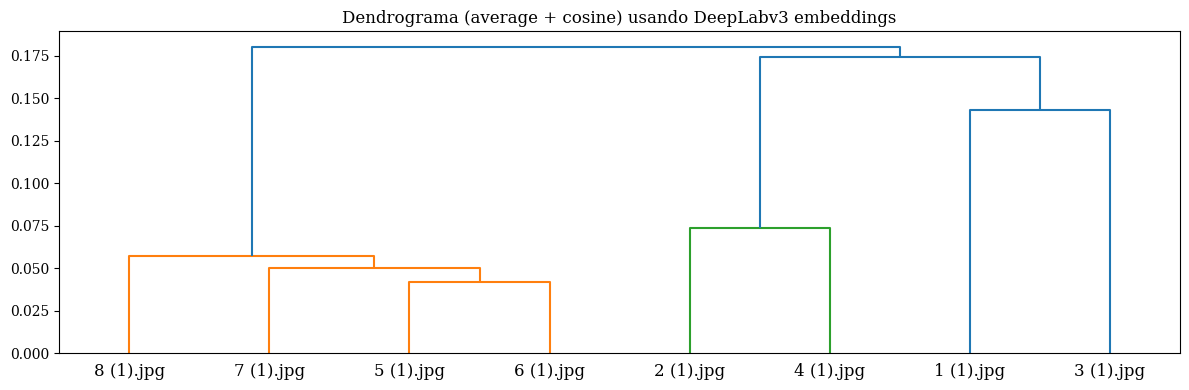

In [45]:
plt.figure(figsize=(12, 4))
dendrogram(Z, labels=names, leaf_rotation=0)
plt.title("Dendrograma (average + cosine) usando DeepLabv3 embeddings")
plt.tight_layout()
plt.show()

In [46]:
k = 2
labels = fcluster(Z, t=k, criterion="maxclust")
list(zip(names, labels))

[('1 (1).jpg', np.int32(2)),
 ('2 (1).jpg', np.int32(2)),
 ('3 (1).jpg', np.int32(2)),
 ('4 (1).jpg', np.int32(2)),
 ('5 (1).jpg', np.int32(1)),
 ('6 (1).jpg', np.int32(1)),
 ('7 (1).jpg', np.int32(1)),
 ('8 (1).jpg', np.int32(1))]

In [47]:
def show_clusters(img_paths, names, labels, cols=4):
    clusters = defaultdict(list)
    name_to_path = {os.path.basename(p): p for p in img_paths}

    for n, lab in zip(names, labels):
        clusters[int(lab)].append(name_to_path[n])

    for lab in sorted(clusters.keys()):
        ps = clusters[lab]
        n = len(ps)
        rows = int(np.ceil(n / cols))

        plt.figure(figsize=(cols*3, rows*3))
        for i, p in enumerate(ps):
            ax = plt.subplot(rows, cols, i+1)
            ax.imshow(Image.open(p).convert("RGB"))
            ax.set_title(os.path.basename(p), fontsize=10)
            ax.axis("off")
        plt.suptitle(f"Cluster {lab} (n={len(ps)})", fontsize=14)
        plt.tight_layout()
        plt.show()



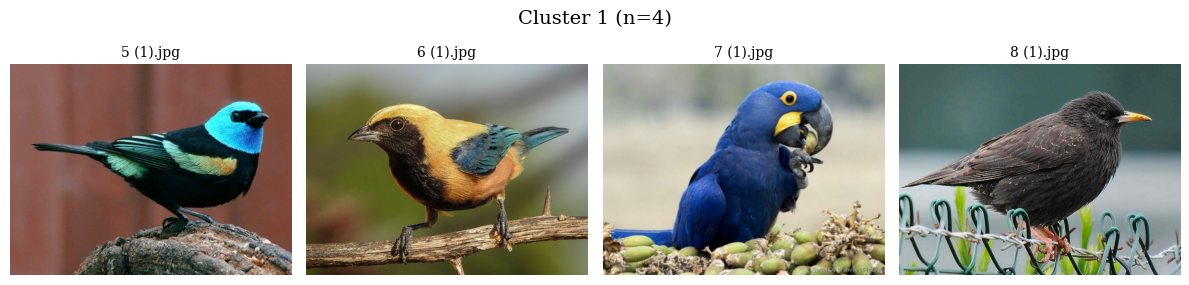

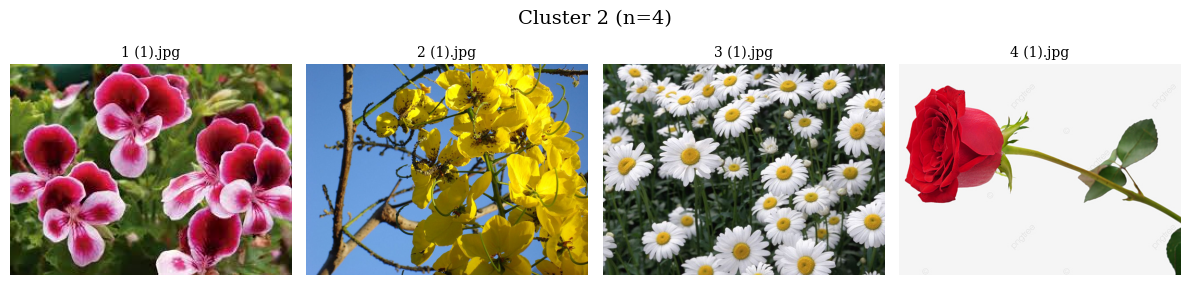

In [48]:
show_clusters(img_paths, names, labels, cols=4)